
Step 2: Loading Dataset...
Data Loaded Successfully.
X Shape: (232, 24, 14) (Patients, 24 Hours, Features)
y Shape: (232,) (Labels)

Step 3: Splitting Data (70% Train, 15% Val, 15% Test)...
Train Set: (162, 24, 14)
Val Set:   (35, 24, 14)
Test Set:  (35, 24, 14)

Step 4: Scaling Features...
Scaling completed.

Step 5: Building LSTM Model...


c:\AINutriCare\Nutricare\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 24, 64)         │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,673 (127.63 KB)

 Trainable params: 32,673 (127.63 KB)

 Non-trainable params: 0 (0.00 B)


Step 6: Training Model...
Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.6914 - loss: 0.6558 - val_accuracy: 0.9143 - val_loss: 0.5592
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8642 - loss: 0.5452 - val_accuracy: 0.9143 - val_loss: 0.4549
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9012 - loss: 0.4399 - val_accuracy: 0.9143 - val_loss: 0.3423
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.9136 - loss: 0.3213 - val_accuracy: 0.9429 - val_loss: 0.2347
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9259 - loss: 0.2357 - val_accuracy: 0.9429 - val_loss: 0.1613
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9444 - loss: 0.1935 - val_accuracy: 0.9429 - val_loss: 0.1331
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9321 - loss: 0.1814 - val_accuracy: 0.9429 - val_loss: 0.1416
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9568 - loss: 0.1514 - val_accuracy:

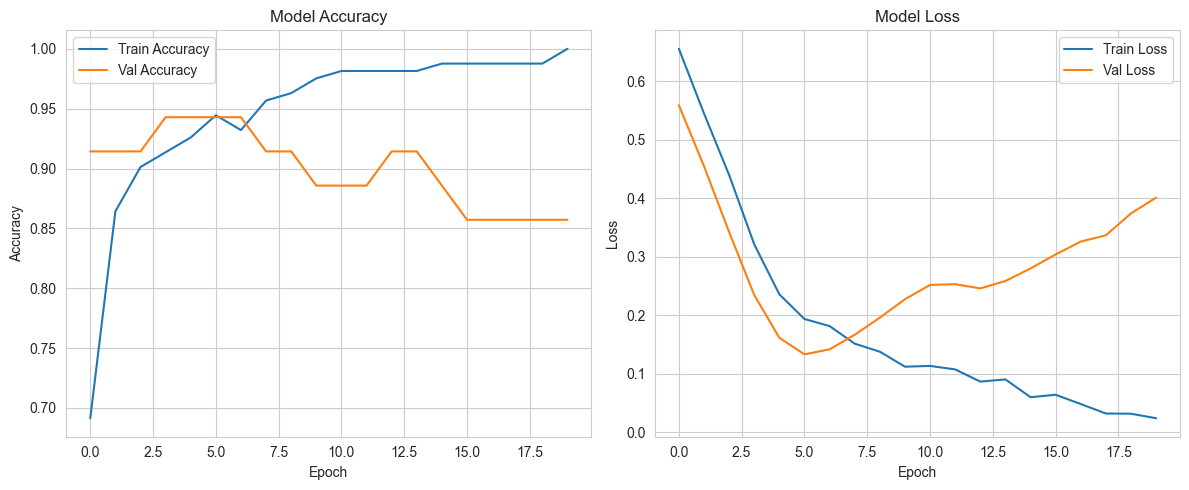


Step 8: Evaluating on Test Set...
Test Accuracy: 91.43%
Test Loss: 0.2256

Step 9 & 10: Detailed Metrics...
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step

Classification Report:
              precision    recall  f1-score   support

    Survived       1.00      0.91      0.95        33
     Expired       0.40      1.00      0.57         2

    accuracy                           0.91        35
   macro avg       0.70      0.95      0.76        35
weighted avg       0.97      0.91      0.93        35



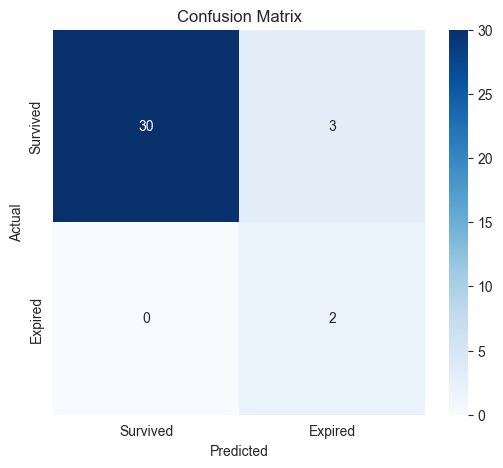


Step 11: Saving Model...
SUCCESS: Model saved to: C:\AINutriCare\Notebooks\Milestone_2\lstm_icu_model.h5


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Set Plotting Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ==========================================
# 1. Configuration & Path Setup
# ==========================================
# Input Path (Where X_final.npy and y_final.npy are located)
data_dir = r"C:\AINutriCare\Data\Transformed"

# Output Path (Where the model will be saved)
save_dir = r"C:\AINutriCare\Notebooks\Milestone_2"
os.makedirs(save_dir, exist_ok=True)

def get_input_path(filename):
    return os.path.join(data_dir, filename)

def get_save_path(filename):
    return os.path.join(save_dir, filename)

# ==========================================
# 2. Load Final Dataset (npy files)
# ==========================================
print("\nStep 2: Loading Dataset...")
try:
    X = np.load(get_input_path('X_final.npy'))
    y = np.load(get_input_path('y_final.npy'))
    
    print(f"Data Loaded Successfully.")
    print(f"X Shape: {X.shape} (Patients, 24 Hours, Features)")
    print(f"y Shape: {y.shape} (Labels)")
    
except FileNotFoundError:
    print(f"Error: Could not find .npy files in {data_dir}")
    exit()

# ==========================================
# 3. Train / Validation / Test Split
# ==========================================
print("\nStep 3: Splitting Data (70% Train, 15% Val, 15% Test)...")

# First split: 70% Train, 30% Temp (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Second split: Split Temp into 50% Val, 50% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train Set: {X_train.shape}")
print(f"Val Set:   {X_val.shape}")
print(f"Test Set:  {X_test.shape}")

# ==========================================
# 4. Feature Scaling (VERY IMPORTANT)
# ==========================================
print("\nStep 4: Scaling Features...")

scaler = StandardScaler()

# Flatten time dimension for scaling: (Patients * 24, Features)
X_train_flat = X_train.reshape(-1, X_train.shape[2])
X_val_flat = X_val.reshape(-1, X_val.shape[2])
X_test_flat = X_test.reshape(-1, X_test.shape[2])

# Fit only on training data to prevent data leakage
scaler.fit(X_train_flat)

# Transform all sets
X_train_scaled = scaler.transform(X_train_flat).reshape(X_train.shape)
X_val_scaled = scaler.transform(X_val_flat).reshape(X_val.shape)
X_test_scaled = scaler.transform(X_test_flat).reshape(X_test.shape)

print("Scaling completed.")

# ==========================================
# 5. Build LSTM Model
# ==========================================
print("\nStep 5: Building LSTM Model...")

model = Sequential([
    # Layer 1: LSTM with return_sequences=True to pass sequences to next LSTM
    LSTM(64, input_shape=(24, X_train.shape[2]), return_sequences=True),
    Dropout(0.3),  # Prevent overfitting
    
    # Layer 2: LSTM without return_sequences (output is a single vector)
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    
    # Output Layer: Sigmoid for binary classification (0-1 probability)
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ==========================================
# 6. Train the Model
# ==========================================
print("\nStep 6: Training Model...")

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,        # You can increase this if the model is still learning
    batch_size=32,
    verbose=1
)

# ==========================================
# 7. Plot Training Curves
# ==========================================
print("\nStep 7: Plotting Learning Curves...")

# Accuracy Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ==========================================
# 8. Evaluate on Test Set
# ==========================================
print("\nStep 8: Evaluating on Test Set...")
loss, acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {acc*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

# ==========================================
# 9 & 10. Classification Report & Confusion Matrix
# ==========================================
print("\nStep 9 & 10: Detailed Metrics...")

# Get predictions
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Survived', 'Expired']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Survived', 'Expired'], 
            yticklabels=['Survived', 'Expired'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ==========================================
# 11. Save Model
# ==========================================
print("\nStep 11: Saving Model...")
model_path = get_save_path('lstm_icu_model.h5')
model.save(model_path)
print(f"SUCCESS: Model saved to: {model_path}")